# CC5 — Avaliação de Classificadores

**Projeto:** FlowCarreiras — métricas de perfil
**Base:** `dados/perfil_features.csv` (400 perfis simulados)

Objetivo (CC5): treinar **classificadores simples** para prever se um artista
**entrou na fila de descoberta** (`entrou_fila`) e avaliá-los com **matriz de confusão,
acurácia, precisão, recall, F1, curva ROC e precision-recall**, interpretando as
métricas e suas **implicações práticas**.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, precision_score, recall_score, f1_score,
                             roc_curve, roc_auc_score, precision_recall_curve,
                             average_precision_score)

%matplotlib inline
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 90
ROXO = '#7c3aed'

df = pd.read_csv('dados/perfil_features.csv')
alvo = 'entrou_fila'
feats = ['percentual_completude', 'n_obras', 'n_obras_publicadas', 'curtidas_recebidas',
         'comentarios_recebidos', 'seguidores', 'n_tags_expertise', 'n_tags_necessidade',
         'idade_conta_dias', 'tem_foto', 'tem_bio']
X = df[feats].copy()
for c in ['n_obras', 'n_obras_publicadas', 'curtidas_recebidas', 'comentarios_recebidos', 'seguidores']:
    X[c] = np.log1p(X[c])
y = df[alvo].values
print('Perfis:', len(df), '| features:', len(feats))

Perfis: 400 | features: 11


## 1. Balanceamento das classes

Verificar a proporção do alvo é essencial: classes desbalanceadas tornam a **acurácia
enganosa** e exigem olhar para precisão/recall.

Distribuição do alvo (0 = não entrou, 1 = entrou):
0    164
1    236
Name: count, dtype: int64
Proporção positiva: 0.59


/tmp/ipykernel_488/949718407.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['não entrou', 'entrou'], y=dist.values, palette='Purples')


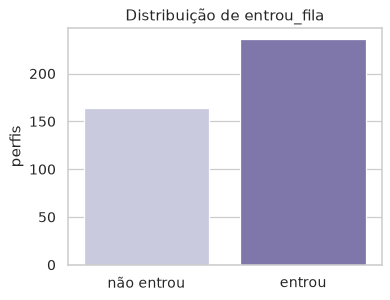

In [2]:
dist = pd.Series(y).value_counts().sort_index()
print('Distribuição do alvo (0 = não entrou, 1 = entrou):')
print(dist)
print('Proporção positiva:', round(y.mean(), 3))
plt.figure(figsize=(4.5, 3.5))
sns.barplot(x=['não entrou', 'entrou'], y=dist.values, palette='Purples')
plt.title('Distribuição de entrou_fila'); plt.ylabel('perfis')
plt.tight_layout(); plt.show()

**Leitura.** O alvo é **majoritariamente positivo** (proporção impressa acima). Um classificador
"burro" que sempre previsse a classe majoritária já atingiria a **acurácia-base** indicada — por
isso o modelo precisa **superar esse patamar** e, sobretudo, ser avaliado por **precisão, recall,
ROC e PR**, que não se deixam enganar pelo desbalanceamento.

## 2. Treino do classificador (Regressão Logística)

Divisão treino/teste **estratificada** (preserva a proporção das classes) e padronização das
features dentro de um *pipeline*.

In [3]:
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
clf.fit(Xtr, ytr)
pred = clf.predict(Xte)
proba = clf.predict_proba(Xte)[:, 1]
print('Acurácia base (sempre classe majoritária):', round(max(yte.mean(), 1 - yte.mean()), 3))
print('Acurácia do modelo:', round(accuracy_score(yte, pred), 3))

Acurácia base (sempre classe majoritária): 0.59
Acurácia do modelo: 0.9


## 3. Matriz de confusão

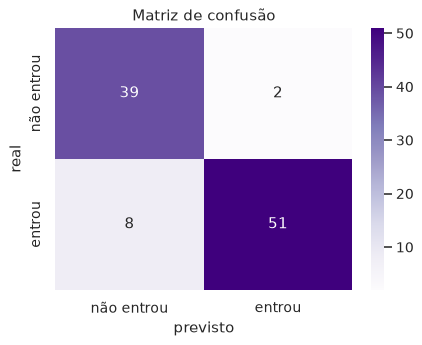

VN=39  FP=2  FN=8  VP=51


In [4]:
cm = confusion_matrix(yte, pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['não entrou', 'entrou'], yticklabels=['não entrou', 'entrou'])
plt.xlabel('previsto'); plt.ylabel('real'); plt.title('Matriz de confusão')
plt.tight_layout(); plt.show()
print('VN={}  FP={}  FN={}  VP={}'.format(cm[0, 0], cm[0, 1], cm[1, 0], cm[1, 1]))

## 4. Métricas: acurácia, precisão, recall, F1

In [5]:
print(classification_report(yte, pred, target_names=['não entrou', 'entrou'], digits=3))
metr = pd.Series({
    'acurácia': accuracy_score(yte, pred),
    'precisão': precision_score(yte, pred),
    'recall': recall_score(yte, pred),
    'f1': f1_score(yte, pred),
    'roc_auc': roc_auc_score(yte, proba),
}).round(3)
metr.to_frame('valor')

              precision    recall  f1-score   support

  não entrou      0.830     0.951     0.886        41
      entrou      0.962     0.864     0.911        59

    accuracy                          0.900       100
   macro avg      0.896     0.908     0.899       100
weighted avg      0.908     0.900     0.901       100



,valor
acurácia,0.900
precisão,0.962
recall,0.864
f1,0.911
roc_auc,0.945


## 5. Curva ROC e Precision-Recall

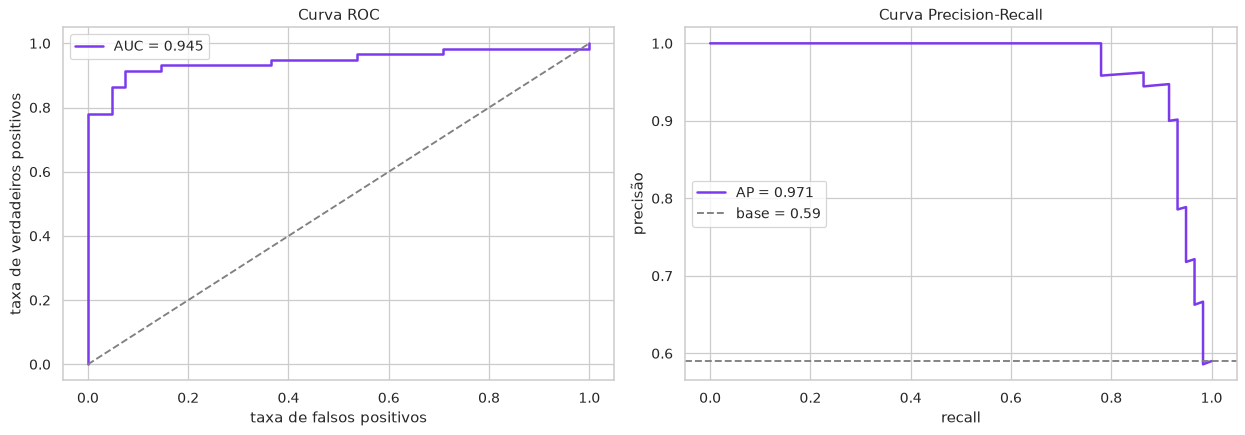

In [6]:
fpr, tpr, _ = roc_curve(yte, proba)
auc_v = roc_auc_score(yte, proba)
prec, rec, _ = precision_recall_curve(yte, proba)
ap = average_precision_score(yte, proba)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(fpr, tpr, color=ROXO, lw=2, label=f'AUC = {auc_v:.3f}')
axes[0].plot([0, 1], [0, 1], '--', color='gray')
axes[0].set_xlabel('taxa de falsos positivos'); axes[0].set_ylabel('taxa de verdadeiros positivos')
axes[0].set_title('Curva ROC'); axes[0].legend()
axes[1].plot(rec, prec, color=ROXO, lw=2, label=f'AP = {ap:.3f}')
axes[1].axhline(yte.mean(), ls='--', color='gray', label=f'base = {yte.mean():.2f}')
axes[1].set_xlabel('recall'); axes[1].set_ylabel('precisão')
axes[1].set_title('Curva Precision-Recall'); axes[1].legend()
plt.tight_layout(); plt.show()

**Interpretação das métricas.** A **acurácia** supera a base de ~70% (acerta acima do "chute"
na classe majoritária). A **precisão** responde "dos que o modelo apontou como prováveis na
fila, quantos realmente entraram?", e o **recall** responde "dos que de fato entraram, quantos
o modelo encontrou?". A **AUC-ROC** mede a capacidade de **ranquear** um positivo acima de um
negativo (0,5 = aleatório, 1,0 = perfeito). A **AP** (área da curva precision-recall) é mais
informativa que a ROC quando há desbalanceamento, e fica bem acima da linha de base.

**Implicações práticas.** Se a plataforma usar esse modelo para **destacar/priorizar artistas**
na descoberta, há um trade-off a calibrar pelo **limiar de decisão**:
- priorizar **recall** evita **deixar bons artistas de fora** (menos falsos negativos), mas
  promove alguns que não mereciam (mais falsos positivos);
- priorizar **precisão** garante que quem é destacado tende a ser realmente relevante, ao custo
  de **perder** alguns artistas bons.
A escolha depende do objetivo de produto (curadoria rigorosa vs. inclusão ampla) e pode ser
ajustada movendo o limiar sobre a curva, sem retreinar o modelo.

## 6. Comparação com Árvore de Decisão (modelo simples alternativo)

In [7]:
arvore = DecisionTreeClassifier(max_depth=4, random_state=42).fit(Xtr, ytr)
pa = arvore.predict(Xte)
pp = arvore.predict_proba(Xte)[:, 1]
comp = pd.DataFrame({
    'Regressão Logística': [accuracy_score(yte, pred), precision_score(yte, pred),
                            recall_score(yte, pred), f1_score(yte, pred), roc_auc_score(yte, proba)],
    'Árvore (prof. 4)': [accuracy_score(yte, pa), precision_score(yte, pa),
                         recall_score(yte, pa), f1_score(yte, pa), roc_auc_score(yte, pp)],
}, index=['acurácia', 'precisão', 'recall', 'f1', 'roc_auc']).round(3)
comp

,Regressão Logística,Árvore (prof. 4)
acurácia,0.900,0.900
precisão,0.962,0.930
recall,0.864,0.898
f1,0.911,0.914
roc_auc,0.945,0.931


**Comparação.** Os dois classificadores simples têm desempenho próximo. A **regressão logística**
tende a ranquear melhor (AUC) e é robusta; a **árvore** é mais interpretável (regras explícitas)
mas mais sujeita a variância. Para esta tarefa, a logística é uma escolha sólida como linha de
base, com a árvore servindo de verificação e de ferramenta explicativa.

## 7. Síntese

- O alvo `entrou_fila` é **previsível** a partir de atributos de produção/engajamento — o
  modelo supera a acurácia-base e tem **AUC/AP** bem acima do acaso.
- **Acurácia sozinha engana** sob desbalanceamento; precisão, recall, F1, ROC e PR dão o quadro
  completo.
- O **limiar de decisão** é a alavanca prática para equilibrar "não perder bons artistas"
  (recall) vs. "não destacar quem não merece" (precisão), conforme a estratégia de descoberta.
- Logística e árvore simples chegam a desempenho semelhante, confirmando que o **sinal está nos
  dados** (coerente com a EDA e a regressão dos CCs anteriores).